In [7]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from tqdm import tqdm
import time

def coupang_crawl(search, page):
    options = uc.ChromeOptions()
    options.add_argument("--start-maximized")

    driver = uc.Chrome(options=options, version_main=145)

    href_list = []

    # 1페이지부터 page페이지까지 href 수집
    for p in range(1, page + 1):
        driver.get(f"https://www.coupang.com/np/search?component=&q={search}&traceId=mmll3jcw&channel=user&page={p}")
        time.sleep(2)

        link = driver.find_elements(By.CSS_SELECTOR, 'li.ProductUnit_productUnit__Qd6sv>a')
        for i in range(len(link)):
            href = link[i].get_attribute('href')
            if href not in href_list:
                href_list.append(href)

    f = open(f'./data/쿠팡_{search}.txt', 'w', encoding='utf-8')

    # 컬럼명
    f.write("name|price\n")

    for i in tqdm(range(len(href_list))):
        try:
            driver.get(href_list[i])
            time.sleep(2)

            # 상품명
            name = driver.find_element(
                By.CSS_SELECTOR,
                'div.twc-flex.twc-justify-between.twc-items-start > div > h1'
            ).text

            # 가격
            price = driver.find_element(
                By.CSS_SELECTOR,
                'div.final-price.twc-flex.twc-items-center.twc-flex-wrap > div'
            ).text

            # 파일 저장
            f.write(f"{name}|{price}\n")

        except:
            continue

    f.close()
    driver.quit()

    return '추출 완료'

In [8]:
coupang_crawl("소형세탁기", 10)

100%|██████████| 360/360 [18:34<00:00,  3.09s/it]


'추출 완료'

,name,price
0,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"
1,독일 기술 미니 듀얼 세탁기 휴대용 분리식 세탁 속옷 양말나눠 빨래용 세탁기 가정 ...,"29,900원"
2,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
3,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
4,마이디어 통돌이 세탁기 MAS07W70/WK-KR 7kg 방문설치,"220,450원"
...,...,...
178,레드퍼피 강아지용 슬립 펫스텝 3단,"32,200원"
179,"프롬코튼 미용타올 90g 면사, 진회색, 10개","18,900원"
180,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"
181,마메 프리미엄 쿠션 원형 방석,"13,500원"


In [9]:
import pandas as pd
df = pd.read_csv('./data/쿠팡_소형세탁기.txt', sep='|')
print(f"로딩 완료: {df.shape}")
df

로딩 완료: (183, 2)


,name,price
0,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"
1,독일 기술 미니 듀얼 세탁기 휴대용 분리식 세탁 속옷 양말나눠 빨래용 세탁기 가정 ...,"29,900원"
2,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
3,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
4,마이디어 통돌이 세탁기 MAS07W70/WK-KR 7kg 방문설치,"220,450원"
...,...,...
178,레드퍼피 강아지용 슬립 펫스텝 3단,"32,200원"
179,"프롬코튼 미용타올 90g 면사, 진회색, 10개","18,900원"
180,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"
181,마메 프리미엄 쿠션 원형 방석,"13,500원"


In [10]:
df = df[
    df['name'].str.contains('세탁기') &
    df['name'].str.contains('소형|세탁기')
]
df = df.reset_index(drop=True)
df

,name,price
0,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"
1,독일 기술 미니 듀얼 세탁기 휴대용 분리식 세탁 속옷 양말나눠 빨래용 세탁기 가정 ...,"29,900원"
2,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
3,GBED 독일기술 가정용 미니 소형 세탁기 UV 살균 아기세탁기 여행용 속옷 양말 ...,"32,000원"
4,마이디어 통돌이 세탁기 MAS07W70/WK-KR 7kg 방문설치,"220,450원"
...,...,...
99,<신규한정>대웅 전자동 세탁기 3.5kg 화이트,"169,000원"
100,위니아 입체물살 세탁기 12kg 방문설치,"318,000원"
101,하이얼 6kg 화이트 소형 일반 통돌이세탁기 HWMW9J60MW,"239,000원"
102,클린솔 가정용 운동화세탁기 소형 미니 속옷 신발 행주 양말 운동복 손빨래 1인용 분리,"139,000원"


In [11]:
df.to_csv('./data/쿠팡_소형세탁기.csv', index=False, encoding='utf-8-sig')

In [17]:
df['price_num'] = df['price'].str.replace('원','').str.replace(',','').astype(int)

In [19]:
df.sort_values('price_num', ascending=True)

,name,price,price_num
86,드럼 세탁기커버 건조기 덮개 방수 매트 김치 냉장고 커버,"8,800원",8800
55,PYHO 탈수기능 휴대용 미니 세탁기 캠핑 수관 속옷 양말 여행용 소형세탁기,"19,800원",19800
61,Purevia 초소형 무선 미니세탁기 속옷 양말 아기옷 전용 여행 원룸 휴대용 필수품,"21,900원",21900
71,BLACK K7 소형세탁기 무선 충전식 여행용 휴대용 2kg 양말 속옷 미니 세탁기,"24,150원",24150
53,BLACK K7 소형세탁기 무선 충전식 여행용 휴대용 2kg 양말 속옷 미니 세탁기,"24,150원",24150
...,...,...,...
46,위니아 클라쎄 소형세탁기 7kg 자취방 세탁기 (기사방문설치),"269,000원",269000
100,위니아 입체물살 세탁기 12kg 방문설치,"318,000원",318000
9,LG전자 통돌이세탁기 10kg 방문설치,"335,680원",335680
6,삼성전자 아가사랑 세탁기 3kg 방문설치,"377,440원",377440


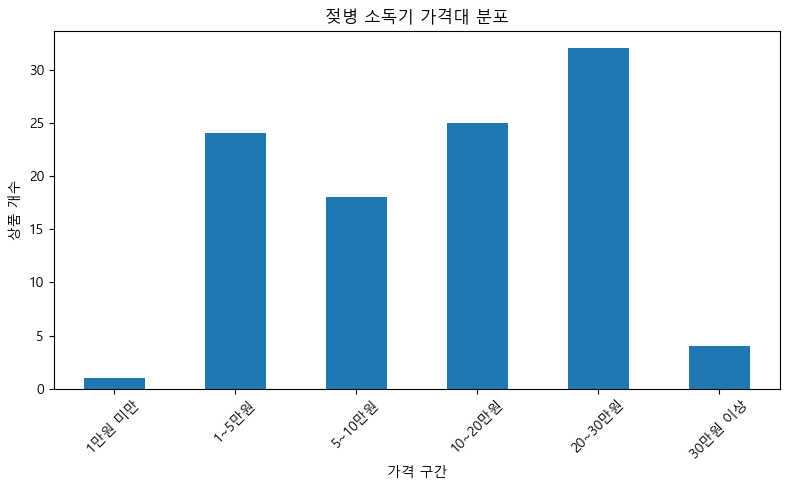

In [20]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 가격 구간 설정
bins = [0,10000,50000,100000,200000,300000,10000000]
labels = [
    '1만원 미만',
    '1~5만원',
    '5~10만원',
    '10~20만원',
    '20~30만원',
    '30만원 이상'
]

df['price_range'] = pd.cut(df['price_num'], bins=bins, labels=labels)

# 개수 집계
price_count = df['price_range'].value_counts().sort_index()

# 그래프
plt.figure(figsize=(8,5))
price_count.plot(kind='bar')

plt.title('젖병 소독기 가격대 분포')
plt.xlabel('가격 구간')
plt.ylabel('상품 개수')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()